# Importing and meshing custom airfoils from .dat files

In this tutorial, we will demonstrate how to import airfoils outside the NACA family from `.dat` files. The type of formating MikFoil uses for imported airfoil data is standardized by the Selig format, which is one of the most common ways to provide data for airfoil geometries.  You can find many airfoils in this format to import for free on the [Airfoil Tools](http://airfoiltools.com/) website.

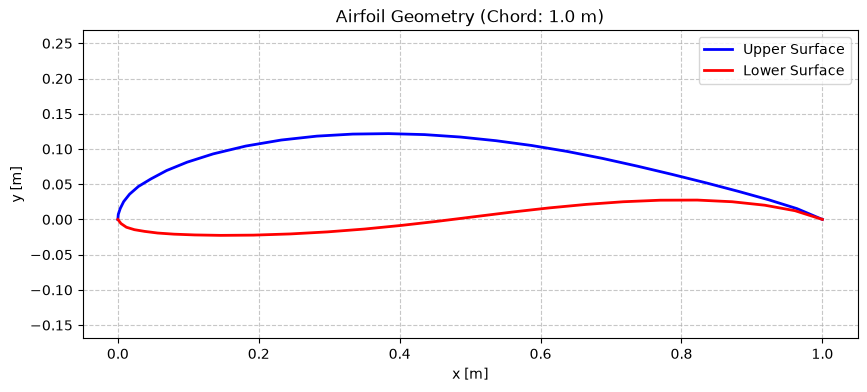

In [1]:
from mikfoil.case import MeshConfig
from mikfoil.geometry import create_airfoil_from_file, plot_airfoil
from pathlib import Path

# Let's load a Wortmann FX 63-137 airfoil from a Selig format .dat file
config = MeshConfig()
wortmann_path = Path("data/fx63137.dat")
wortmann_geom = create_airfoil_from_file(wortmann_path, config)

# Visualize to see the airfoil shape
plot_airfoil(wortmann_geom, show=True)

When you import an airfoil into mikfoil, the program resamples the points to match the `s_le`, `s_mid` and `s_te` values specified in config.

In [2]:
from mikfoil.meshing import generate_mesh
from mikfoil.meshing.mesh_visualisation import visualize_mesh_interactive

# We can mesh imported airfoils in the exact same way as NACA airfoils generated by the program
wortmann_grid = generate_mesh(wortmann_geom, config)

# Visualize
visualize_mesh_interactive(wortmann_grid)


Widget(value='<iframe src="http://localhost:52673/index.html?ui=P_0x2966b94aa50_0&reconnect=auto" class="pyvis…

As you can see meshing an imported airfoil is very similar to what we did in **Tutorial 1**.

One important thing to take note of is the [boundary flags](https://su2code.github.io/docs_v7/Markers-and-BC/) required by SU2 solver to perform a simulation (`farfield` and `airfoil`). Those are generated automatically by the mesher but if you would like to write your own config for SU2 analysis, and want to use other boundary conditions than farfield, keep that in mind.


In [3]:
from mikfoil.meshing import export_su2_mesh, export_vtk_mesh
from IPython.display import Markdown, display,Code

# We can export the mesh to SU2 format to use it in a CFD simulation
export_su2_mesh(wortmann_grid, "data/wortmann.su2")

#Or into .vts format used by Paraview
export_vtk_mesh(wortmann_grid, "data/wortmann.vts")

#Let's also print the top of a SU2 mehs file to get familiar with the format
with open("data/wortmann.su2", "r") as file:
    top_lines = "".join([file.readline() for _ in range(15)])
print(top_lines)


NDIME= 2
NELEM= 15048
9 0 100 101 1
9 1 101 102 2
9 2 102 103 3
9 3 103 104 4
9 4 104 105 5
9 5 105 106 6
9 6 106 107 7
9 7 107 108 8
9 8 108 109 9
9 9 109 110 10
9 10 110 111 11
9 11 111 112 12
9 12 112 113 13



MikFoil simulation module relies on SU2, that's also why this is a default format of the mesher module. However it is possible to export or convert the generated mesh into some other formats, for now only vtk, but in the future I plan on expanding the export capabilities to other common mesh formats. 